# LUMO Inference Demo

Interactive inference-time notebook for the trained support agent.

This demo shows:
- Natural-language agent and customer turns
- Per-turn environment variables and metrics
- Live turn-by-turn playback
- Batch evaluation and transcript export

Default checkpoint: `Simulation_4/artifacts/phase10_prod/models/best_model.zip`


In [13]:
!pip install ipywidgets

## 1. Project Paths, Imports, and Runtime Checks

In [14]:
import json
import os
import sys
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gymnasium as gym
import ipywidgets as widgets
from IPython.display import HTML, clear_output, display
from stable_baselines3 import PPO

# Resolve repo root BEFORE importing project modules.
cwd = Path.cwd().resolve()
repo_root = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "Simulation_4").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError(
        "Could not find repository root containing Simulation_4. "
        "Open this notebook from inside the project workspace."
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from Simulation_4.env.agent_response_generator import AgentResponseGenerator
from Simulation_4.env.support_env import SupportEnv
from Simulation_4.training.nlp_observation import NLPObservationWrapper
from Simulation_4.training.text_observation import TextOnlyObservationWrapper

artifacts_root = repo_root / "Simulation_4" / "artifacts"
checkpoint_candidates = [
    artifacts_root / "phase10_prod" / "models" / "best_model.zip",
    artifacts_root / "phase10_prod" / "models" / "final_model.zip",
    artifacts_root / "phase10_final" / "models" / "best_model.zip",
    artifacts_root / "phase10_final" / "models" / "final_model.zip",
]

print(f"Repo root: {repo_root}")
print(f"Artifacts root: {artifacts_root}")
print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"ipywidgets available: {widgets is not None}")
print("Candidate checkpoints:")
for path in checkpoint_candidates:
    print(f"  - {path} {'(exists)' if path.exists() else '(missing)'}")

Repo root: /Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service
Artifacts root: /Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation_4/artifacts
Python: 3.14.0
NumPy: 2.4.3
Pandas: 3.0.1
ipywidgets available: True
Candidate checkpoints:
  - /Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation_4/artifacts/phase10_prod/models/best_model.zip (exists)
  - /Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation_4/artifacts/phase10_prod/models/final_model.zip (exists)
  - /Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation_4/artifacts/phase10_final/models/best_model.zip (exists)
  - /Users/tishabhavsar/RL_Project /AdaptiveBandit--C

## 2. Load Trained PPO Checkpoint and Build Inference Environment

In [21]:
MODEL_PATH = next((p for p in checkpoint_candidates if p.exists()), None)
if MODEL_PATH is None:
    raise FileNotFoundError("No PPO checkpoint found in phase10_prod/phase10_final.")

ACTION_NAMES = {
    0: "AskInfo",
    1: "ProvideSolution",
    2: "AffectiveRepair",
    3: "Escalate",
    4: "Close",
}

DEFAULT_SEED = 90000
DEFAULT_MAX_TURNS = 20
DEFAULT_DETERMINISTIC = True

print(f"Loading PPO model from: {MODEL_PATH}")
model = PPO.load(str(MODEL_PATH), device="cpu")
model_obs_dim = int(np.prod(model.observation_space.shape))
print(f"Model observation space: {model.observation_space} ({model_obs_dim} dims)")
print(f"Action space: {model.action_space}")


def resolve_lumo_subflow_filter() -> list[str]:
    mapping_path = repo_root / "Simulation_4" / "rag" / "subflow_mapping.json"
    if not mapping_path.exists():
        return []
    try:
        payload = json.loads(mapping_path.read_text(encoding="utf-8"))
    except Exception:
        return []
    if not isinstance(payload, dict):
        return []
    return sorted([str(k) for k, v in payload.items() if isinstance(k, str) and isinstance(v, dict)])


LUMO_SUBFLOW_FILTER = resolve_lumo_subflow_filter()
if LUMO_SUBFLOW_FILTER:
    print(f"LUMO subflow filter active ({len(LUMO_SUBFLOW_FILTER)} subflows from subflow_mapping.json)")
else:
    print("Warning: LUMO subflow mapping unavailable; using full environment subflow distribution.")


class PadObservationWrapper(gym.Wrapper):
    def __init__(self, env: gym.Env, target_dim: int, agent_response_generator: AgentResponseGenerator | None = None):
        super().__init__(env)
        self.target_dim = int(target_dim)
        self.agent_response_generator = agent_response_generator
        self.observation_space = gym.spaces.Box(low=-1.0, high=1.0, shape=(self.target_dim,), dtype=np.float32)

    @property
    def state(self) -> dict[str, Any]:
        return getattr(self.env, "state", {})

    @property
    def ACTION_NAMES(self) -> dict[int, str]:
        return getattr(self.env, "ACTION_NAMES", ACTION_NAMES)

    def _pad(self, obs: np.ndarray) -> np.ndarray:
        obs = np.asarray(obs, dtype=np.float32).reshape(-1)
        padded = np.zeros(self.target_dim, dtype=np.float32)
        limit = min(len(obs), self.target_dim)
        padded[:limit] = obs[:limit]
        return padded

    def reset(self, *, seed: int | None = None, options: dict | None = None):
        obs, info = self.env.reset(seed=seed, options=options)
        return self._pad(obs), info

    def step(self, action: int):
        action_name = self.ACTION_NAMES.get(int(action), f"Action{int(action)}")
        agent_text = None
        if self.agent_response_generator is not None:
            try:
                history = list(getattr(self.env, "conversation_history", []))
                agent_text = self.agent_response_generator.generate(
                    action_name=action_name,
                    conversation_history=history,
                    policy_context=str(getattr(self.env, "rag_context", {}).get("policy_context", "")),
                    classification=None,
                )
            except Exception:
                agent_text = None
        obs, reward, done, truncated, info = self.env.step(int(action), agent_text=agent_text)
        return self._pad(obs), reward, done, truncated, info


def build_inference_env():
    base_env = SupportEnv(
        artifacts_root=str(artifacts_root),
        nlg_enabled=True,
        subflow_filter=(LUMO_SUBFLOW_FILTER or None),
    )
    if model_obs_dim == 9:
        wrapped_env = NLPObservationWrapper(base_env, agent_response_generator=AgentResponseGenerator())
        wrapper_name = "NLPObservationWrapper"
    elif model_obs_dim == 386:
        wrapped_env = TextOnlyObservationWrapper(base_env)
        wrapper_name = "TextOnlyObservationWrapper"
    else:
        wrapped_env = PadObservationWrapper(base_env, target_dim=model_obs_dim, agent_response_generator=AgentResponseGenerator())
        wrapper_name = f"PadObservationWrapper({model_obs_dim})"
    return wrapped_env, wrapper_name

inference_env, wrapper_name = build_inference_env()
print(f"Chosen inference wrapper: {wrapper_name}")
print(f"Wrapped observation space: {inference_env.observation_space}")
print(f"Wrapped action space: {inference_env.action_space}")


@dataclass
class TurnRecord:
    turn: int
    action_id: int
    action: str
    reward: float
    cumulative_reward: float
    terminal_type: str
    turn_count: int
    progress: float
    information: float
    frustration: float
    failed_streak: int
    resolved: int
    escalated: int
    dropped_off: int
    tier: str
    persona: str
    lumo_label: str
    display_name: str
    agent_text: str
    customer_text: str
    transition: dict[str, Any] = field(default_factory=dict)


print("Model and environment ready.")

Loading PPO model from: /Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation_4/artifacts/phase10_prod/models/best_model.zip
Model observation space: Box(0.0, 1.0, (9,), float32) (9 dims)
Action space: Discrete(5)
LUMO subflow filter active (95 subflows from subflow_mapping.json)
DocumentStore loaded:
  lumo_doc1_company_product_overview.md: 22 chunks
  lumo_doc2_support_policies.md: 48 chunks
  lumo_doc3_issue_playbooks.md: 59 chunks
  Total chunks: 129
  Mean chunk size: 787 characters
  Min chunk size: 45 characters
  Max chunk size: 1000 characters


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Chosen inference wrapper: NLPObservationWrapper
Wrapped observation space: Box(0.0, 1.0, (9,), float32)
Wrapped action space: Discrete(5)
Model and environment ready.


## 3. Natural-Language Rendering Layer for State and Agent Action

In [16]:
def safe_float(value: Any, default: float = 0.0) -> float:
    try:
        return float(value)
    except Exception:
        return float(default)


def extract_latest_messages(history: list[dict[str, str]]) -> tuple[str, str]:
    agent_text = ""
    customer_text = ""
    if not isinstance(history, list):
        return agent_text, customer_text
    for message in reversed(history):
        if not isinstance(message, dict):
            continue
        role = str(message.get("role", "")).strip()
        content = str(message.get("content", "")).strip()
        if not content:
            continue
        if not customer_text and role == "assistant":
            customer_text = content
        elif not agent_text and role == "user":
            agent_text = content
        if agent_text and customer_text:
            break
    return agent_text, customer_text


def state_snapshot(state: dict[str, Any], info: dict[str, Any]) -> dict[str, Any]:
    transition = info.get("last_transition_outcome", {}) if isinstance(info, dict) else {}
    history = info.get("conversation_history", []) if isinstance(info, dict) else []
    agent_text, customer_text = extract_latest_messages(history)
    return {
        "turn_count": int(state.get("turn_count", 0)),
        "progress": round(safe_float(state.get("progress", 0.0)), 4),
        "information": round(safe_float(state.get("information", 0.0)), 4),
        "frustration": round(safe_float(state.get("frustration", 0.0)), 4),
        "failed_streak": int(state.get("failed_streak", 0)),
        "resolved": int(state.get("resolved", 0)),
        "escalated": int(state.get("escalated", 0)),
        "dropped_off": int(state.get("dropped_off", 0)),
        "tier": str(state.get("tier", "unknown")),
        "persona": str(state.get("persona_label", "unknown")),
        "lumo_label": str(state.get("lumo_label", state.get("display_name", "unknown"))),
        "display_name": str(state.get("display_name", state.get("subflow", "unknown"))),
        "terminal_type": str(transition.get("terminal_type", "")),
        "outcome": str(transition.get("outcome", "")),
        "agent_text": agent_text,
        "customer_text": customer_text,
        "slots_revealed": transition.get("slots_revealed", []),
        "terminal_reward": round(safe_float(transition.get("terminal_reward", 0.0)), 4),
        "per_turn_reward": round(safe_float(transition.get("per_turn_reward", 0.0)), 4),
    }


def transcript_html(history: list[dict[str, str]], max_messages: int = 12) -> str:
    items = []
    if not isinstance(history, list):
        history = []
    for message in history[-max_messages:]:
        role = str(message.get("role", "")).strip().title() or "Unknown"
        content = str(message.get("content", "")).strip()
        color = "#0f766e" if role.lower() == "user" else "#7c2d12"
        if role.lower() == "assistant":
            role = "Customer"
        elif role.lower() == "user":
            role = "Agent"
        items.append(
            f'<div style="margin:0.25rem 0; padding:0.4rem 0.6rem; border-left:4px solid {color}; background:#fafafa;">'
            f'<div style="font-size:0.78rem; font-weight:700; color:{color}; margin-bottom:0.15rem;">{role}</div>'
            f'<div style="white-space:pre-wrap; line-height:1.35;">{content}</div>'
            f'</div>'
        )
    return "".join(items) if items else '<div style="color:#666;">No transcript yet.</div>'


def build_metrics_df(turn_log: list[TurnRecord]) -> pd.DataFrame:
    if not turn_log:
        return pd.DataFrame()
    frame = pd.DataFrame([record.__dict__ for record in turn_log])
    return frame


print("State rendering helpers ready.")

State rendering helpers ready.


## 4. Step-Level Inference Function and Live Episode Runner

In [17]:
class DemoEpisode:
    def __init__(self, model: PPO, env: gym.Env, seed: int, deterministic: bool = True, max_turns: int = 20):
        self.model = model
        self.env = env
        self.seed = int(seed)
        self.deterministic = bool(deterministic)
        self.max_turns = int(max_turns)
        self.reset()

    def reset(self):
        self.obs, self.info = self.env.reset(seed=self.seed)
        self.done = False
        self.turn_log: list[TurnRecord] = []
        self.cumulative_reward = 0.0
        self.turn_index = 0
        self.last_state = dict(getattr(self.env, "state", {}))
        return self.obs, self.info

    def predict_action(self) -> tuple[int, float | None]:
        action, _ = self.model.predict(self.obs, deterministic=self.deterministic)
        return int(action), None

    def step(self, action_id: int | None = None) -> TurnRecord:
        if self.done:
            raise RuntimeError("Episode already finished. Reset the demo to start a new one.")
        if self.turn_index >= self.max_turns:
            self.done = True
            raise RuntimeError("Reached the maximum turn cap for this demo episode.")

        if action_id is None:
            action_id, _ = self.predict_action()
        action_id = int(action_id)
        action_name = ACTION_NAMES.get(action_id, f"Action{action_id}")

        self.obs, reward, done, truncated, info = self.env.step(action_id)
        self.cumulative_reward += float(reward)
        self.turn_index += 1
        self.last_state = dict(getattr(self.env, "state", {}))

        snapshot = state_snapshot(self.last_state, info)
        record = TurnRecord(
            turn=self.turn_index,
            action_id=action_id,
            action=action_name,
            reward=float(reward),
            cumulative_reward=float(self.cumulative_reward),
            terminal_type=str(snapshot.get("terminal_type", "")),
            turn_count=int(snapshot.get("turn_count", 0)),
            progress=float(snapshot.get("progress", 0.0)),
            information=float(snapshot.get("information", 0.0)),
            frustration=float(snapshot.get("frustration", 0.0)),
            failed_streak=int(snapshot.get("failed_streak", 0)),
            resolved=int(snapshot.get("resolved", 0)),
            escalated=int(snapshot.get("escalated", 0)),
            dropped_off=int(snapshot.get("dropped_off", 0)),
            tier=str(snapshot.get("tier", "unknown")),
            persona=str(snapshot.get("persona", "unknown")),
            lumo_label=str(snapshot.get("lumo_label", "unknown")),
            display_name=str(snapshot.get("display_name", "unknown")),
            agent_text=str(snapshot.get("agent_text", "")),
            customer_text=str(snapshot.get("customer_text", "")),
            transition=dict(info.get("last_transition_outcome", {}) or {}),
        )
        self.turn_log.append(record)
        self.info = info
        self.done = bool(done or truncated or self.turn_index >= self.max_turns)
        return record

    def run_to_end(self):
        while not self.done:
            self.step()
        return self.turn_log

    def to_frame(self) -> pd.DataFrame:
        return build_metrics_df(self.turn_log)


print("DemoEpisode class ready.")

DemoEpisode class ready.


## 5. Interactive Controls with ipywidgets

In [18]:
class DemoUI:
    def __init__(self, model: PPO):
        self.model = model
        self.episode: DemoEpisode | None = None
        self.wrapper_name: str = ""
        self.env: gym.Env | None = None

        self.seed_input = widgets.IntText(value=DEFAULT_SEED, description="Seed:")
        self.max_turns_input = widgets.Dropdown(
            options=[(str(v), v) for v in range(5, 51)],
            value=int(DEFAULT_MAX_TURNS),
            description="Max Turns:",
        )
        self.det_checkbox = widgets.Checkbox(value=DEFAULT_DETERMINISTIC, description="Deterministic")
        self.action_dropdown = widgets.Dropdown(
            options=[("Policy (model.predict)", -1)] + [(f"{idx}: {name}", idx) for idx, name in ACTION_NAMES.items()],
            value=-1,
            description="Action:",
        )

        self.reset_button = widgets.Button(description="Reset Episode", button_style="warning")
        self.step_button = widgets.Button(description="Step Once", button_style="primary")
        self.run_button = widgets.Button(description="Run To End (Policy)", button_style="success")

        self.behavior_hint = widgets.HTML(
            value=(
                "<div style='font-size:0.82rem; color:#334155; margin:0.2rem 0 0.35rem 0;'>"
                "Run To End always uses the learned policy. The Action dropdown is only used for Step Once."
                "</div>"
            )
        )

        self.status_html = widgets.HTML()
        self.transcript_html = widgets.HTML(value='<div style="color:#666;">No transcript yet.</div>')
        self.metrics_output = widgets.Output()

        self.reset_button.on_click(self._on_reset)
        self.step_button.on_click(self._on_step_once)
        self.run_button.on_click(self._on_run_to_end)

    def _current_seed(self) -> int:
        value = self.seed_input.value
        return int(DEFAULT_SEED if value is None else value)

    def _current_max_turns(self) -> int:
        value = self.max_turns_input.value
        return int(DEFAULT_MAX_TURNS if value is None else value)

    def _close_env(self):
        if self.env is not None:
            try:
                self.env.close()
            except Exception:
                pass
        self.env = None

    def _create_episode(self):
        self._close_env()
        self.env, self.wrapper_name = build_inference_env()
        self.episode = DemoEpisode(
            model=self.model,
            env=self.env,
            seed=self._current_seed(),
            deterministic=bool(self.det_checkbox.value),
            max_turns=self._current_max_turns(),
        )
        self._refresh()

    def _status_block(self, latest: TurnRecord | None) -> str:
        if self.episode is None:
            return "<div style='color:#666;'>Episode not initialized.</div>"
        state = dict(getattr(self.episode.env, "state", {}))
        transition_info = self.episode.info if isinstance(self.episode.info, dict) else {}
        snap = state_snapshot(state, transition_info)
        if latest is None and self.episode.turn_log:
            latest = self.episode.turn_log[-1]

        detail_rows = [
            f"<b>Wrapper</b>: {self.wrapper_name}",
            f"<b>Turn</b>: {self.episode.turn_index} / {self.episode.max_turns}",
            f"<b>Cumulative Reward</b>: {self.episode.cumulative_reward:.4f}",
            f"<b>Progress</b>: {snap.get('progress', 0.0)}",
            f"<b>Information</b>: {snap.get('information', 0.0)}",
            f"<b>Frustration</b>: {snap.get('frustration', 0.0)}",
            f"<b>Persona</b>: {snap.get('persona', 'unknown')}",
            f"<b>LUMO Label</b>: {snap.get('lumo_label', 'unknown')}",
            f"<b>Terminal Type</b>: {snap.get('terminal_type', '') or '-'}",
        ]

        if latest is not None:
            detail_rows.append(f"<b>Last Action</b>: {latest.action} ({latest.action_id})")
            detail_rows.append(f"<b>Last Reward</b>: {latest.reward:.4f}")

        banner_color = "#14532d" if self.episode.done else "#0f172a"
        banner_text = "Episode finished" if self.episode.done else "Episode active"
        return (
            f"<div style='padding:0.65rem 0.8rem; border:1px solid #e5e7eb; border-radius:0.5rem; background:#f8fafc;'>"
            f"<div style='font-weight:700; color:{banner_color}; margin-bottom:0.4rem;'>{banner_text}</div>"
            f"<div style='line-height:1.55;'>{'<br/>'.join(detail_rows)}</div>"
            f"</div>"
        )

    def _refresh(self):
        latest = self.episode.turn_log[-1] if self.episode and self.episode.turn_log else None
        self.status_html.value = self._status_block(latest)

        history = []
        if self.episode is not None and isinstance(self.episode.info, dict):
            history = self.episode.info.get("conversation_history", []) or []
        self.transcript_html.value = transcript_html(history, max_messages=16)

        with self.metrics_output:
            clear_output(wait=True)
            if self.episode is None:
                print("Episode not initialized.")
                return
            frame = self.episode.to_frame()
            if frame.empty:
                print("No turns yet. Click 'Step Once' or 'Run To End (Policy)'.")
            else:
                display(frame.tail(20))

    def _on_reset(self, _):
        self._create_episode()

    def _on_step_once(self, _):
        if self.episode is None:
            self._create_episode()
        if self.episode is None or self.episode.done:
            self._refresh()
            return
        chosen = int(self.action_dropdown.value)
        action_id = None if chosen < 0 else chosen
        self.episode.step(action_id=action_id)
        self._refresh()

    def _on_run_to_end(self, _):
        if self.episode is None:
            self._create_episode()
        if self.episode is None:
            return
        while not self.episode.done:
            self.episode.step(action_id=None)
        self._refresh()

    def render(self):
        controls = widgets.HBox([self.seed_input, self.max_turns_input, self.det_checkbox])
        actions = widgets.HBox([self.action_dropdown, self.step_button, self.run_button, self.reset_button])
        transcript_box = widgets.VBox([widgets.HTML("<h4 style='margin:0.2rem 0;'>Conversation Transcript</h4>"), self.transcript_html])
        metrics_box = widgets.VBox([widgets.HTML("<h4 style='margin:0.2rem 0;'>Turn Metrics</h4>"), self.metrics_output])
        root = widgets.VBox([controls, self.behavior_hint, actions, self.status_html, transcript_box, metrics_box])
        self._create_episode()
        return root


demo_ui = DemoUI(model=model)
display(demo_ui.render())
print("Interactive demo controls ready.")

DocumentStore loaded:
  lumo_doc1_company_product_overview.md: 22 chunks
  lumo_doc2_support_policies.md: 48 chunks
  lumo_doc3_issue_playbooks.md: 59 chunks
  Total chunks: 129
  Mean chunk size: 787 characters
  Min chunk size: 45 characters
  Max chunk size: 1000 characters


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Interactive demo controls ready.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

## 6. Batch Evaluation Utilities
Run multiple seeded episodes to get aggregate quality metrics and outcome distributions.

In [19]:
def run_batch_episodes(
    n_episodes: int = 25,
    seed_start: int = DEFAULT_SEED,
    deterministic: bool = DEFAULT_DETERMINISTIC,
    max_turns: int = DEFAULT_MAX_TURNS,
) -> tuple[pd.DataFrame, list[dict[str, Any]]]:
    records: list[dict[str, Any]] = []
    transcripts: list[dict[str, Any]] = []

    for episode_idx in range(int(n_episodes)):
        seed = int(seed_start) + episode_idx
        env, chosen_wrapper = build_inference_env()
        runner = DemoEpisode(
            model=model,
            env=env,
            seed=seed,
            deterministic=bool(deterministic),
            max_turns=int(max_turns),
        )

        try:
            runner.run_to_end()
            frame = runner.to_frame()
            final = runner.turn_log[-1] if runner.turn_log else None
            info = runner.info if isinstance(runner.info, dict) else {}
            transition = info.get("last_transition_outcome", {}) if isinstance(info, dict) else {}
            history = info.get("conversation_history", []) if isinstance(info, dict) else []

            records.append(
                {
                    "episode": episode_idx + 1,
                    "seed": seed,
                    "wrapper": chosen_wrapper,
                    "turns": int(len(runner.turn_log)),
                    "cumulative_reward": float(runner.cumulative_reward),
                    "mean_turn_reward": float(frame["reward"].mean()) if not frame.empty else 0.0,
                    "terminal_type": str(transition.get("terminal_type", "")),
                    "resolved": int(final.resolved) if final is not None else 0,
                    "escalated": int(final.escalated) if final is not None else 0,
                    "dropped_off": int(final.dropped_off) if final is not None else 0,
                    "persona": str(final.persona) if final is not None else "unknown",
                    "lumo_label": str(final.lumo_label) if final is not None else "unknown",
                }
            )
            transcripts.append(
                {
                    "episode": episode_idx + 1,
                    "seed": seed,
                    "history": history,
                    "terminal": transition,
                }
            )
        finally:
            try:
                env.close()
            except Exception:
                pass

    return pd.DataFrame(records), transcripts


def summarize_batch(batch_df: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, Any]]:
    if batch_df.empty:
        return pd.DataFrame(), {}

    summary = {
        "episodes": int(len(batch_df)),
        "mean_cumulative_reward": float(batch_df["cumulative_reward"].mean()),
        "std_cumulative_reward": float(batch_df["cumulative_reward"].std(ddof=0)),
        "mean_turns": float(batch_df["turns"].mean()),
        "resolution_rate": float(batch_df["resolved"].mean()),
        "escalation_rate": float(batch_df["escalated"].mean()),
        "dropoff_rate": float(batch_df["dropped_off"].mean()),
    }

    outcome_table = (
        batch_df.groupby("terminal_type", dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )
    return outcome_table, summary


print("Batch evaluation helpers ready.")

Batch evaluation helpers ready.


## 7. Run Batch Report and Export Artifacts
Execute this cell to generate aggregate metrics, quick plots, and saved outputs under active_sim_logs.

DocumentStore loaded:
  lumo_doc1_company_product_overview.md: 22 chunks
  lumo_doc2_support_policies.md: 48 chunks
  lumo_doc3_issue_playbooks.md: 59 chunks
  Total chunks: 129
  Mean chunk size: 787 characters
  Min chunk size: 45 characters
  Max chunk size: 1000 characters


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

DocumentStore loaded:
  lumo_doc1_company_product_overview.md: 22 chunks
  lumo_doc2_support_policies.md: 48 chunks
  lumo_doc3_issue_playbooks.md: 59 chunks
  Total chunks: 129
  Mean chunk size: 787 characters
  Min chunk size: 45 characters
  Max chunk size: 1000 characters


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

DocumentStore loaded:
  lumo_doc1_company_product_overview.md: 22 chunks
  lumo_doc2_support_policies.md: 48 chunks
  lumo_doc3_issue_playbooks.md: 59 chunks
  Total chunks: 129
  Mean chunk size: 787 characters
  Min chunk size: 45 characters
  Max chunk size: 1000 characters


...

DocumentStore loaded:
  lumo_doc1_company_product_overview.md: 22 chunks
  lumo_doc2_support_policies.md: 48 chunks
  lumo_doc3_issue_playbooks.md: 59 chunks
  Total chunks: 129
  Mean chunk size: 787 characters
  Min chunk size: 45 characters
  Max chunk size: 1000 characters


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

,episode,seed,wrapper,turns,cumulative_reward,mean_turn_reward,terminal_type,resolved,escalated,dropped_off,persona,lumo_label
0,1,90000,NLPObservationWrapper,4,-4.614568,-1.153642,escalation,0,0,0,unknown,unknown
1,2,90001,NLPObservationWrapper,4,-2.611848,-0.652962,escalation,0,0,0,unknown,unknown
2,3,90002,NLPObservationWrapper,4,-1.120234,-0.280059,escalation,0,0,0,unknown,unknown
3,4,90003,NLPObservationWrapper,4,-4.605216,-1.151304,escalation,0,0,0,unknown,unknown
4,5,90004,NLPObservationWrapper,4,-2.630270,-0.657567,escalation,0,0,0,unknown,unknown
5,6,90005,NLPObservationWrapper,4,-4.606564,-1.151641,escalation,0,0,0,unknown,unknown
6,7,90006,NLPObservationWrapper,1,-2.384052,-2.384052,dropout,0,0,0,unknown,unknown
7,8,90007,NLPObservationWrapper,4,-1.149755,-0.287439,escalation,0,0,0,unknown,unknown
8,9,90008,NLPObservationWrapper,4,0.336497,0.084124,escalation,0,0,0,unknown,unknown
9,10,90009,NLPObservationWrapper,4,-4.608996,-1.152249,escalation,0,0,0,unknown,unknown


,terminal_type,count
0,escalation,24
1,dropout,1


{
  "episodes": 25,
  "mean_cumulative_reward": -1.8432800015804143,
  "std_cumulative_reward": 1.8478969931407176,
  "mean_turns": 3.88,
  "resolution_rate": 0.0,
  "escalation_rate": 0.0,
  "dropoff_rate": 0.0
}


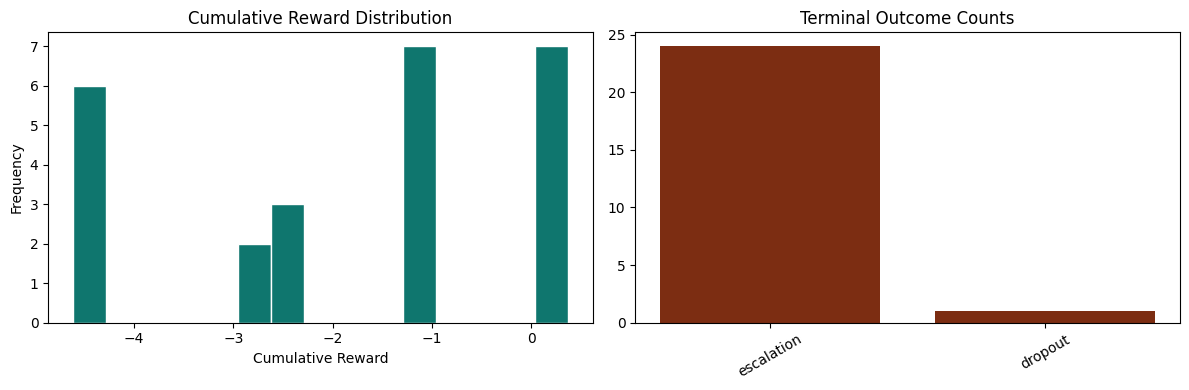

Saved metrics CSV: /Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation_4/artifacts/active_sim_logs/lumo_batch_metrics_20260425_142948.csv
Saved summary JSON: /Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation_4/artifacts/active_sim_logs/lumo_batch_summary_20260425_142948.json
Saved transcripts JSON: /Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation_4/artifacts/active_sim_logs/lumo_batch_transcripts_20260425_142948.json


/var/folders/zj/5gdxx71d3p53ch83fydgddvh0000gn/T/ipykernel_25620/1033535307.py:37: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  stamp = pd.Timestamp.utcnow().strftime("%Y%m%d_%H%M%S")


In [20]:
BATCH_EPISODES = 25
BATCH_SEED_START = DEFAULT_SEED
BATCH_DETERMINISTIC = True
BATCH_MAX_TURNS = DEFAULT_MAX_TURNS

batch_df, batch_transcripts = run_batch_episodes(
    n_episodes=BATCH_EPISODES,
    seed_start=BATCH_SEED_START,
    deterministic=BATCH_DETERMINISTIC,
    max_turns=BATCH_MAX_TURNS,
)

outcome_table, summary = summarize_batch(batch_df)

display(batch_df.head(10))
display(outcome_table)
print(json.dumps(summary, indent=2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
batch_df["cumulative_reward"].plot(kind="hist", bins=15, ax=axes[0], color="#0f766e", edgecolor="white")
axes[0].set_title("Cumulative Reward Distribution")
axes[0].set_xlabel("Cumulative Reward")

if not outcome_table.empty:
    axes[1].bar(outcome_table["terminal_type"].astype(str), outcome_table["count"], color="#7c2d12")
    axes[1].set_title("Terminal Outcome Counts")
    axes[1].tick_params(axis="x", rotation=30)
else:
    axes[1].text(0.5, 0.5, "No terminal outcomes", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

export_dir = artifacts_root / "active_sim_logs"
export_dir.mkdir(parents=True, exist_ok=True)
stamp = pd.Timestamp.utcnow().strftime("%Y%m%d_%H%M%S")

metrics_csv = export_dir / f"lumo_batch_metrics_{stamp}.csv"
summary_json = export_dir / f"lumo_batch_summary_{stamp}.json"
transcript_json = export_dir / f"lumo_batch_transcripts_{stamp}.json"

batch_df.to_csv(metrics_csv, index=False)
with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)
with open(transcript_json, "w", encoding="utf-8") as f:
    json.dump(batch_transcripts, f, indent=2)

print(f"Saved metrics CSV: {metrics_csv}")
print(f"Saved summary JSON: {summary_json}")
print(f"Saved transcripts JSON: {transcript_json}")